# ERPsim 全市场决策辅助看板 (V2 - 利润突破版)

这款看板专门用于**10家公司竞争下的商科ERP模拟比赛**（设定：共4轮，每轮20天，顾客整局偏好不变）。
本脚本不单单通过《市场销售报告.xlsx》来反映表面销售情况，更通过您增加的《商品成本.xlsx》精算出了真正的“单品吸金能力”。

> **核心决策流**：
> 1. **看容量**：在偏好不变的大盘中，找准“最好卖”的大流向，保证排产大方向不错。
> 2. **找现金牛**：由于产能是固定的，如果盲目造“好卖但不挣钱”的货会拉低总收入。我们算出真实的“总利润贡献”，帮你们将机器投入给真正的吸金爆款！
> 3. **卡暴击价**：摸透对手对于“现金牛”都在卖什么价，寻找阻力位，稍微低一点就能吃掉整个市场的高利润蛋糕！\n

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体与负号显示
plt.rcParams['font.sans-serif'] = ['SimHei']  
plt.rcParams['axes.unicode_minus'] = False  

# 全局配置图形风格
sns.set_theme(style="whitegrid", font='SimHei', font_scale=1.0)


## 模块 1：全市场顾客基础偏好容量分析 (找大盘方向)
通过汇总大盘全周期的销售记录，找出最容易出货的蓝海市场基石。
它的意义在于：**当有产能闲置，或者高利润订单被抢光时，这里的头排榜单能帮你们快速走量去库存。**\n

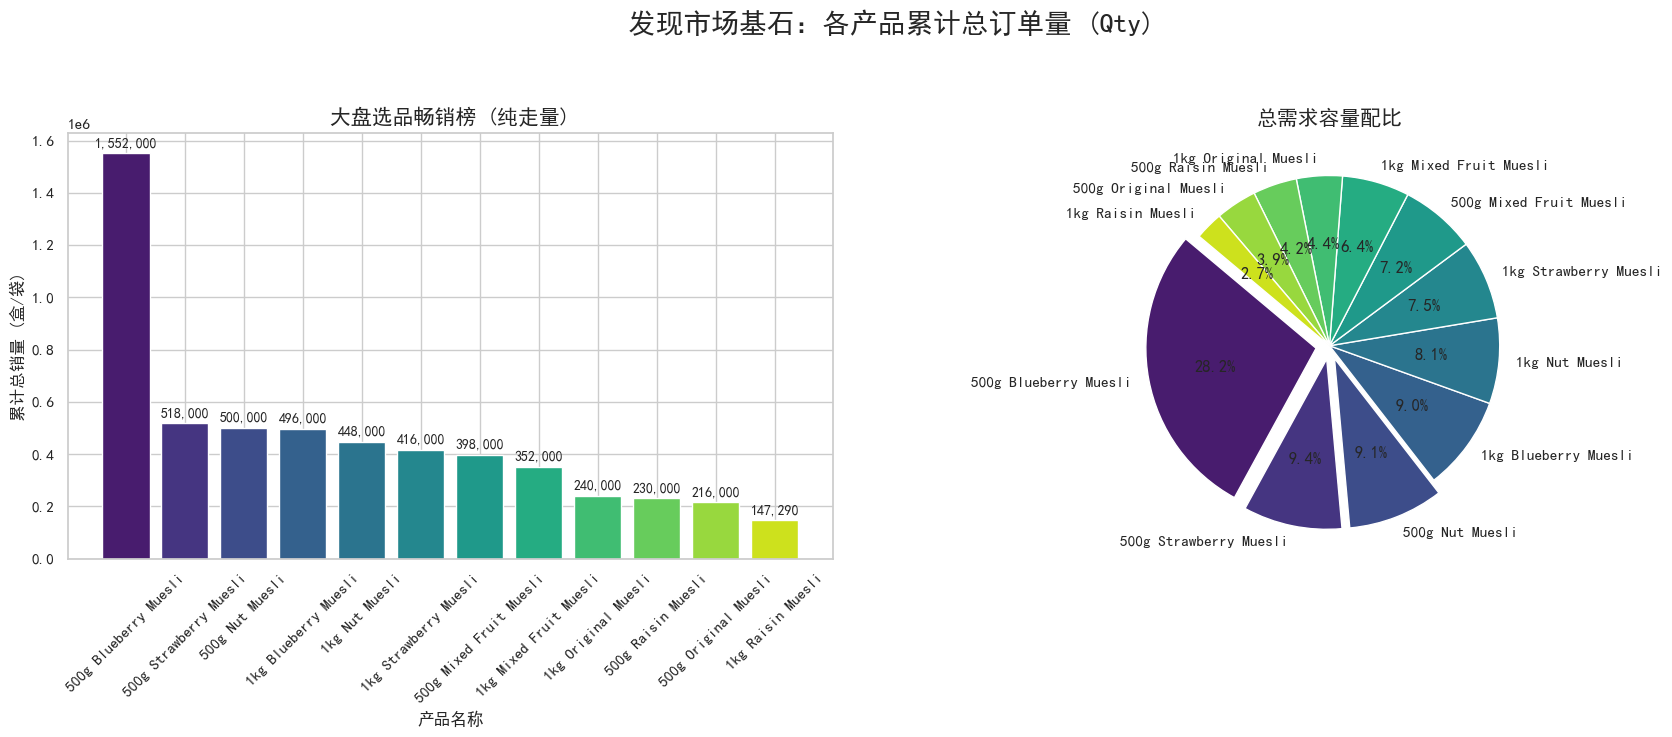

In [2]:
# 1. 挂载《市场销售报告》
df_market = pd.read_excel('市场销售报告.xlsx', sheet_name='Sheet1')
rows, _ = df_market.shape
df_market = df_market.loc[6:rows, ['Unnamed: 1', 'Unnamed: 2', 'Unnamed: 4', 'Unnamed: 6']]
df_market.columns = ['Date', 'Material', 'Qty', 'Price']

# 清洗数据格式
df_market['Date'] = df_market['Date'].astype(str).str.strip()
df_market['Material'] = df_market['Material'].astype(str).str.strip()  # 关键：由于商品名带前置空格必须掐头去尾
df_market['Qty'] = df_market['Qty'].astype(str).str.replace(',', '', regex=True).astype(float)
df_market['Price'] = df_market['Price'].astype(float)

# 算出各产品全市场总计售出量
product_qty_sales = df_market.groupby('Material')['Qty'].sum().sort_values(ascending=False)

# -------- 绘图 --------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('发现市场基石：各产品累计总订单量 (Qty)', fontsize=20, fontweight='bold', y=1.05)

colors = sns.color_palette("viridis", len(product_qty_sales))
bars = ax1.bar(product_qty_sales.index, product_qty_sales.values, color=colors)
ax1.set_title('大盘选品畅销榜 (纯走量)', fontsize=15)
ax1.set_xlabel('产品名称', fontsize=12)
ax1.set_ylabel('累计总销量 (盒/袋)', fontsize=12)
ax1.tick_params(axis='x', rotation=45)

for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval + (product_qty_sales.max()*0.01), 
             f'{int(yval):,}', va='bottom', ha='center', fontsize=10)

explode = [0.08 if i < 3 else 0 for i in range(len(product_qty_sales))]
ax2.pie(product_qty_sales.values, labels=product_qty_sales.index, autopct='%1.1f%%', 
        startangle=140, explode=explode, colors=colors, shadow=False)
ax2.set_title('总需求容量配比', fontsize=15)

plt.tight_layout()
plt.show()


## 模块 2：产品累计净利润（核心印钞机）排行榜 (找最大化价值)
引入了《商品成本.xlsx》。
公式：`单品总利润 = 真实卖出件数 (Qty) × (该笔订单实际成交单价 (Price) - 单位变动固定总成本 (Cost))`。
**它的意义在于**：如果您的工厂每天只能生产固定的最高限额（如 24,000 盒），您一定要优先生产**这幅图表里排行最高**的产品，因为同样耗费一天机器寿命，它带回来的游戏币最多！\n

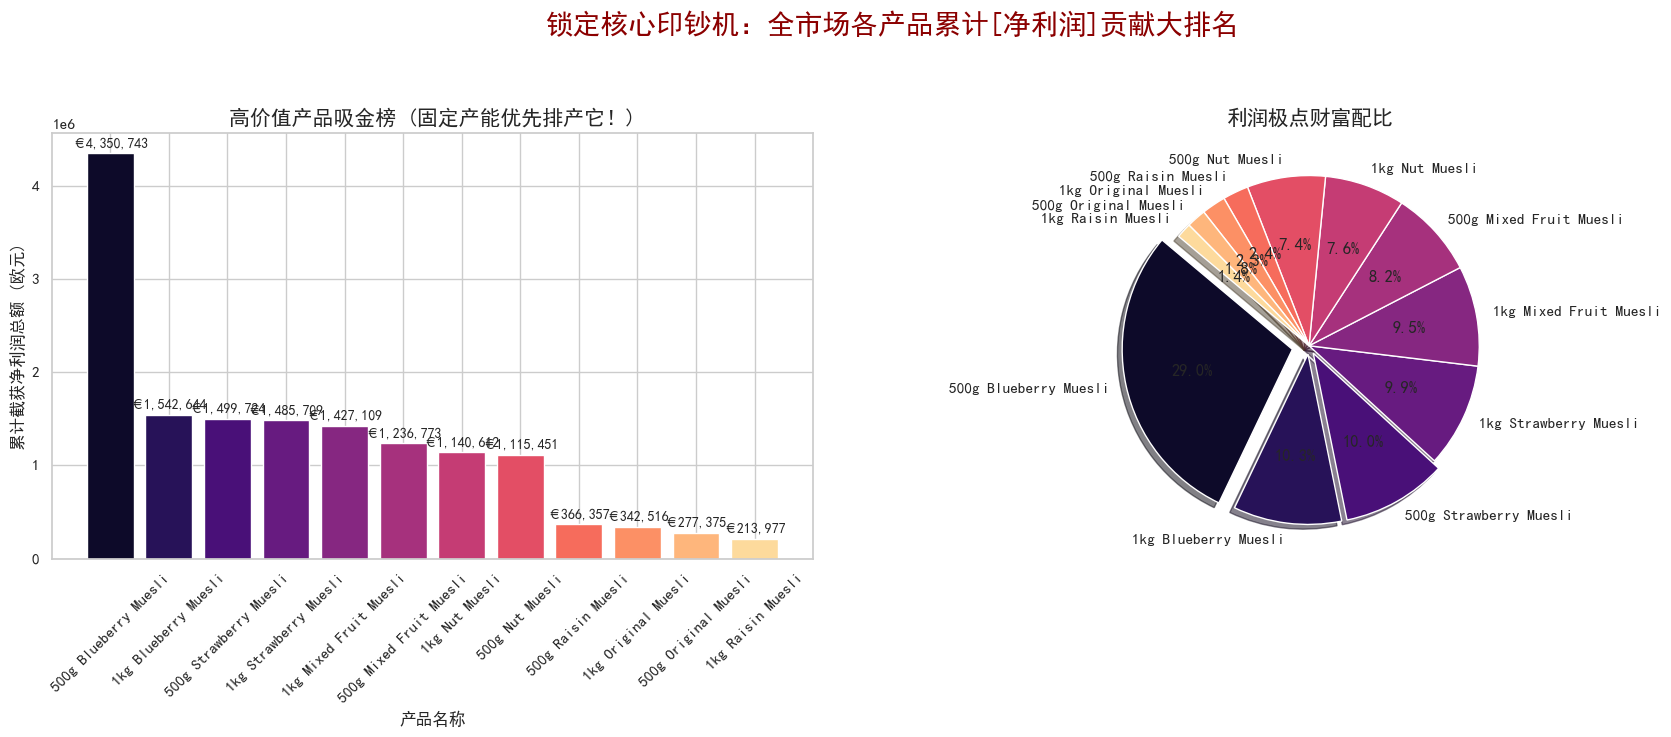

In [3]:
# 2. 挂载《商品成本》进行联合与计算
df_cost = pd.read_excel('商品成本.xlsx')
# 取 Description（第2列） 和 Variable + Fixed总成本（底4列）
df_cost = df_cost.iloc[:, [1, 3]].copy()
df_cost.columns = ['Material', 'Cost']
df_cost['Material'] = df_cost['Material'].astype(str).str.strip()

# 为了计算利润，合并市场报告与成本报告拼起来
# 按照商品通用名字 (Material) 将成本挂接上去
df_profit = pd.merge(df_market, df_cost, on='Material', how='left')

# 找出没有匹配上成本的异常行（通常是0）
missing_cost = df_profit[df_profit['Cost'].isna()]['Material'].unique()
if len(missing_cost) > 0:
    print(f"警告: 以下商品在商品成本.xlsx中未找到匹配项: {missing_cost}")

# 计算每一单生意的纯利润额
# 利润 = 售出量 × (单价 - 成本)
df_profit['Profit'] = df_profit['Qty'] * (df_profit['Price'] - df_profit['Cost'])

# 聚合出每个产品在赛程中为各家公司制造过的“总利润大满贯”
product_profit = df_profit.groupby('Material')['Profit'].sum().sort_values(ascending=False)

# -------- 绘图 --------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('锁定核心印钞机：全市场各产品累计[净利润]贡献大排名', fontsize=20, fontweight='bold', color='darkred', y=1.05)

colors_p = sns.color_palette("magma", len(product_profit))
bars = ax1.bar(product_profit.index, product_profit.values, color=colors_p)
ax1.set_title('高价值产品吸金榜 (固定产能优先排产它！)', fontsize=15, fontweight='bold')
ax1.set_xlabel('产品名称', fontsize=12)
ax1.set_ylabel('累计截获净利润总额 (欧元)', fontsize=12)
ax1.tick_params(axis='x', rotation=45)

for bar in bars:
    yval = bar.get_height()
    # 用欧元符号
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval + (product_profit.max()*0.01), 
             f'€{int(yval):,}', va='bottom', ha='center', fontsize=10)

explode = [0.1 if i == 0 else (0.05 if i < 3 else 0) for i in range(len(product_profit))]
ax2.pie(product_profit.values, labels=product_profit.index, autopct='%1.1f%%', 
        startangle=140, explode=explode, colors=colors_p, shadow=True)
ax2.set_title('利润极点财富配比', fontsize=15)

plt.tight_layout()
plt.show()


## 模块 3：现金牛商品的高额售价阻力带侦测 (卡最优定价点)
上面一步找到了**最高利润贡献品**。那么我们究竟应该对这件产品定多高的价格呢？
这个散布图展示了大盘所有公司每天对于某一产品出的卖价（Price）能够获得的订单销量表现。
* 如果在某个极高的价格点依然有非常可观的销量，并且没人供应，**果断定这个价抢走利润边界**！
* 如果发现在某个价格数字（如 5.50）之后，高价区几乎没有出现过任何成功的订单量点云，**请把您的价格设定在 5.49**，以最高赢利点全部倾销您的产能！\n

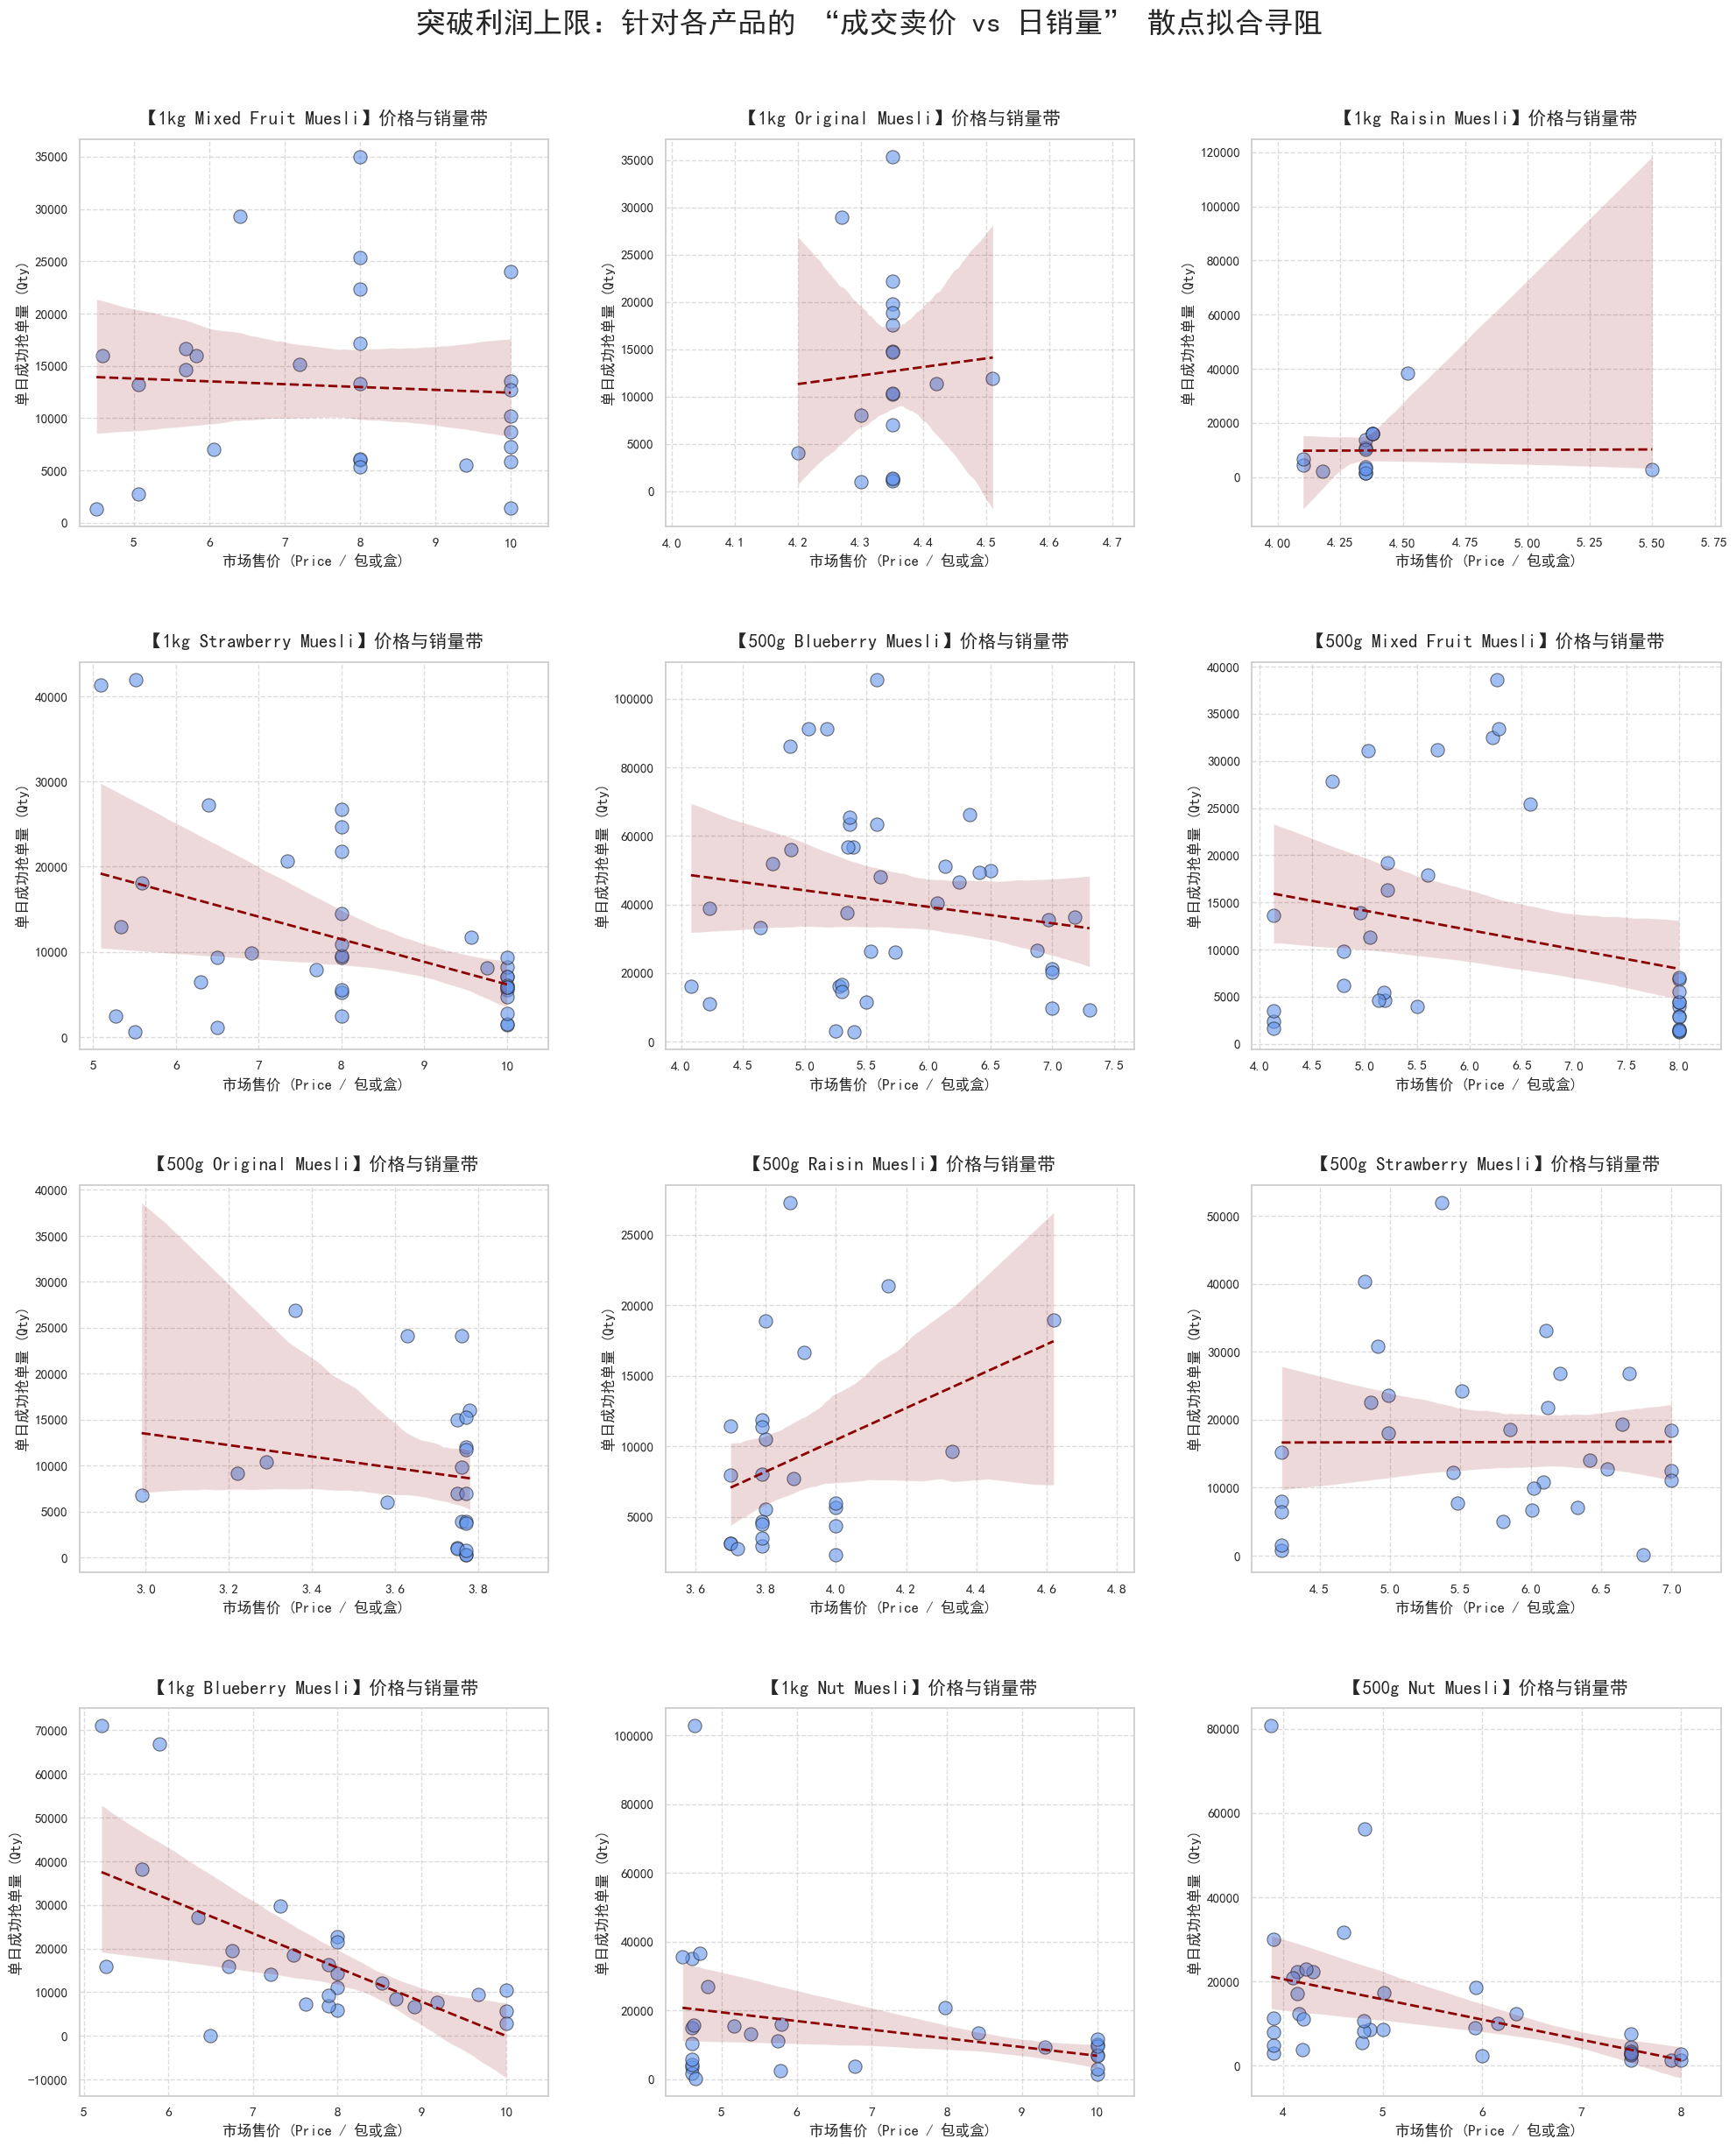

In [4]:
import math

# 过滤为了画出有效的价格散点
df_valid = df_market[(df_market['Qty'] > 0) & (df_market['Price'] > 0)].copy()
products = df_valid['Material'].unique()

n_cols = 3
n_rows = math.ceil(len(products) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 6 * n_rows))
fig.suptitle('突破利润上限：针对各产品的 “成交卖价 vs 日销量” 散点拟合寻阻', fontsize=24, fontweight='bold', y=1.02)

for i, product in enumerate(products):
    ax = axes[i // n_cols, i % n_cols]
    prod_data = df_valid[df_valid['Material'] == product]
    
    sns.scatterplot(
        data=prod_data, 
        x='Price', 
        y='Qty', 
        ax=ax, 
        s=120,          
        alpha=0.6,      
        color='cornflowerblue',
        edgecolor='k',
        linewidth=0.8
    )
    
    # 画出趋势辅助线
    if len(prod_data['Price'].unique()) > 1:
        sns.regplot(
            data=prod_data, 
            x='Price', 
            y='Qty', 
            ax=ax, 
            scatter=False, 
            ci=95,   
            color='darkred',
            line_kws={"linestyle": "dashed", "linewidth": 2}
        )
        
    ax.set_title(f'【{product}】价格与销量带', fontsize=15, pad=12, fontweight='bold')
    ax.set_xlabel('市场售价 (Price / 包或盒)', fontsize=12)
    ax.set_ylabel('单日成功抢单量 (Qty)', fontsize=12)
    
    if len(prod_data) > 0:
        ax.set_xlim(prod_data['Price'].min() * 0.95, prod_data['Price'].max() * 1.05)
        
    ax.grid(True, linestyle='--', alpha=0.7)

for j in range(i + 1, n_rows * n_cols):
    fig.delaxes(axes[j // n_cols, j % n_cols])

plt.tight_layout()
plt.subplots_adjust(hspace=0.35, wspace=0.25)
plt.show()
